# GalaxEye — Binary Change Detection on EO-SAR Image Pairs
**Dataset:** doron333/change-detection-dataset (HuggingFace)  
**Model:** UNet + ResNet34 (early fusion: pre+post concatenated)  
**Task:** Binary pixel-level change detection — Change=1, No-Change=0

---
> **After every session restart**, run cells in order top to bottom.  
> The download cell auto-skips if data already exists on disk.

## CELL 1 — Keep Colab Alive (run this first!)

In [1]:
%%javascript
// Clicks the page every 60s to prevent Colab idle disconnect
function keepAlive() {
    console.log('Keeping Colab alive: ' + new Date().toLocaleTimeString());
}
setInterval(keepAlive, 60000);
console.log('Keep-alive started.');


<IPython.core.display.Javascript object>

## CELL 2 — Install Dependencies

In [2]:
!pip install -q segmentation-models-pytorch==0.3.3
!pip install -q albumentations==1.3.1
!pip install -q huggingface_hub
!pip install -q rasterio
print('All dependencies installed.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 7.7 MB/s eta 0:00:00
All dependencies installed.


## CELL 3 — Download Dataset
> test (195 MB) → val (1 GB) → train (8.8 GB)  
> Already downloaded splits are **skipped automatically**.

In [3]:
import os, zipfile, time
from huggingface_hub import hf_hub_download

# ── Works on both Colab and Kaggle ──
if os.path.exists('/content'):
    DATA_ROOT = '/content/data'
    ZIP_DIR   = '/content/zips'
else:
    DATA_ROOT = '/kaggle/working/data'
    ZIP_DIR   = '/kaggle/working/zips'

REPO_ID = 'doron333/change-detection-dataset'
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(ZIP_DIR,   exist_ok=True)

for split in ['test', 'val', 'train']:
    extract_to = os.path.join(DATA_ROOT, split)
    if os.path.exists(extract_to) and len(os.listdir(extract_to)) > 0:
        print(f'✅ {split} already extracted — skipping.')
        continue
    print(f'⬇️  Downloading {split}.zip ...')
    t0 = time.time()
    zip_path = hf_hub_download(
        repo_id   = REPO_ID,
        filename  = f'{split}.zip',
        repo_type = 'dataset',
        local_dir = ZIP_DIR
    )
    print(f'   Downloaded in {time.time()-t0:.0f}s')
    print(f'📦 Extracting ...')
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    os.remove(zip_path)
    print(f'✅ {split} ready\n')

print('All splits ready!')


⬇️  Downloading test.zip ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


test.zip:   0%|          | 0.00/195M [00:00<?, ?B/s]

   Downloaded in 3s
📦 Extracting ...
✅ test ready

⬇️  Downloading val.zip ...


val.zip:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

   Downloaded in 8s
📦 Extracting ...
✅ val ready

⬇️  Downloading train.zip ...


train.zip:   0%|          | 0.00/8.81G [00:00<?, ?B/s]

   Downloaded in 56s
📦 Extracting ...
✅ train ready

All splits ready!


## CELL 4 — Explore Folder Structure

In [4]:
import os

if os.path.exists('/content'):
    DATA_ROOT = '/content/data'
else:
    DATA_ROOT = '/kaggle/working/data'

for split in ['test', 'val', 'train']:
    split_path = os.path.join(DATA_ROOT, split)
    print(f'\n=== {split.upper()} ===')
    if not os.path.exists(split_path):
        print('  NOT FOUND'); continue
    for root, dirs, files in os.walk(split_path):
        level  = root.replace(split_path, '').count(os.sep)
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/  ({len(files)} files)')
        if files and level < 3:
            for f in files[:3]:
                print(f'{indent}  └─ {f}')
        if level >= 3:
            break



=== TEST ===
test/  (0 files)
  test/  (0 files)
    target/  (77 files)
      └─ scene_10_000010_building_damage.tif
      └─ scene_10_000029_building_damage.tif
      └─ scene_09_000021_building_damage.tif
    post-event/  (77 files)
      └─ scene_10_000010_building_damage.tif
      └─ scene_10_000029_building_damage.tif
      └─ scene_09_000021_building_damage.tif
    pre-event/  (77 files)
      └─ scene_10_000010_building_damage.tif
      └─ scene_10_000029_building_damage.tif
      └─ scene_09_000021_building_damage.tif

=== VAL ===
val/  (0 files)
  val/  (0 files)
    target/  (334 files)
      └─ scene_08_000067_building_damage.tif
      └─ scene_08_000101_building_damage.tif
      └─ scene_02_000007_building_damage.tif
    post-event/  (334 files)
      └─ scene_08_000067_building_damage.tif
      └─ scene_08_000101_building_damage.tif
      └─ scene_02_000007_building_damage.tif
    pre-event/  (334 files)
      └─ scene_08_000067_building_damage.tif
      └─ scene_08_0001

## CELL 5 — Auto-detect Paths & Band Count

In [5]:
import os, numpy as np, rasterio, matplotlib.pyplot as plt
from collections import Counter

if os.path.exists('/content'):
    DATA_ROOT = '/content/data'
else:
    DATA_ROOT = '/kaggle/working/data'


def find_subdir(base, keywords):
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            for kw in keywords:
                if kw.lower() in d.lower():
                    return os.path.join(root, d)
    return None


def get_split_paths(split):
    base = os.path.join(DATA_ROOT, split)
    pre  = find_subdir(base, ['pre-event', 'pre_event', 'pre'])
    post = find_subdir(base, ['post-event', 'post_event', 'post'])
    mask = find_subdir(base, ['target', 'label', 'mask', 'gt'])
    return pre, post, mask


TRAIN_PRE, TRAIN_POST, TRAIN_MASK = get_split_paths('train')
VAL_PRE,   VAL_POST,   VAL_MASK   = get_split_paths('val')
TEST_PRE,  TEST_POST,  TEST_MASK  = get_split_paths('test')

print('Paths:')
for name, path in [
    ('TRAIN_PRE', TRAIN_PRE), ('TRAIN_POST', TRAIN_POST), ('TRAIN_MASK', TRAIN_MASK),
    ('VAL_PRE',   VAL_PRE),   ('VAL_POST',   VAL_POST),   ('VAL_MASK',   VAL_MASK),
    ('TEST_PRE',  TEST_PRE),  ('TEST_POST',  TEST_POST),  ('TEST_MASK',  TEST_MASK),
]:
    count = len(os.listdir(path)) if (path and os.path.exists(path)) else 'NOT FOUND'
    print(f'  {name:<14}: {str(path):<50} ({count} files)')

# ── Band detection — read actual values, no assumptions ──
sample_pre  = sorted(os.listdir(TEST_PRE))[0]
sample_post = sorted(os.listdir(TEST_POST))[0]
sample_mask = sorted(os.listdir(TEST_MASK))[0]

with rasterio.open(os.path.join(TEST_PRE,  sample_pre))  as src:
    N_BANDS_PRE  = src.count
    H, W         = src.height, src.width
with rasterio.open(os.path.join(TEST_POST, sample_post)) as src:
    N_BANDS_POST = src.count

N_BANDS     = N_BANDS_PRE
IN_CHANNELS = N_BANDS_PRE + N_BANDS_POST
EO_BANDS    = N_BANDS_PRE

print(f'\nSample image     : {sample_pre}')
print(f'Image size       : {H} x {W}')
print(f'Pre bands        : {N_BANDS_PRE}')
print(f'Post bands       : {N_BANDS_POST}')
print(f'IN_CHANNELS      : {IN_CHANNELS}  ← model input')


Paths:
  TRAIN_PRE     : /content/data/train/train/pre-event                (2781 files)
  TRAIN_POST    : /content/data/train/train/post-event               (2781 files)
  TRAIN_MASK    : /content/data/train/train/target                   (2781 files)
  VAL_PRE       : /content/data/val/val/pre-event                    (334 files)
  VAL_POST      : /content/data/val/val/post-event                   (334 files)
  VAL_MASK      : /content/data/val/val/target                       (334 files)
  TEST_PRE      : /content/data/test/test/pre-event                  (77 files)
  TEST_POST     : /content/data/test/test/post-event                 (77 files)
  TEST_MASK     : /content/data/test/test/target                     (77 files)

Sample image     : scene_09_000001_building_damage.tif
Image size       : 1024 x 1024
Pre bands        : 3
Post bands       : 1
IN_CHANNELS      : 4  ← model input


## CELL 6 — Visualise One Sample

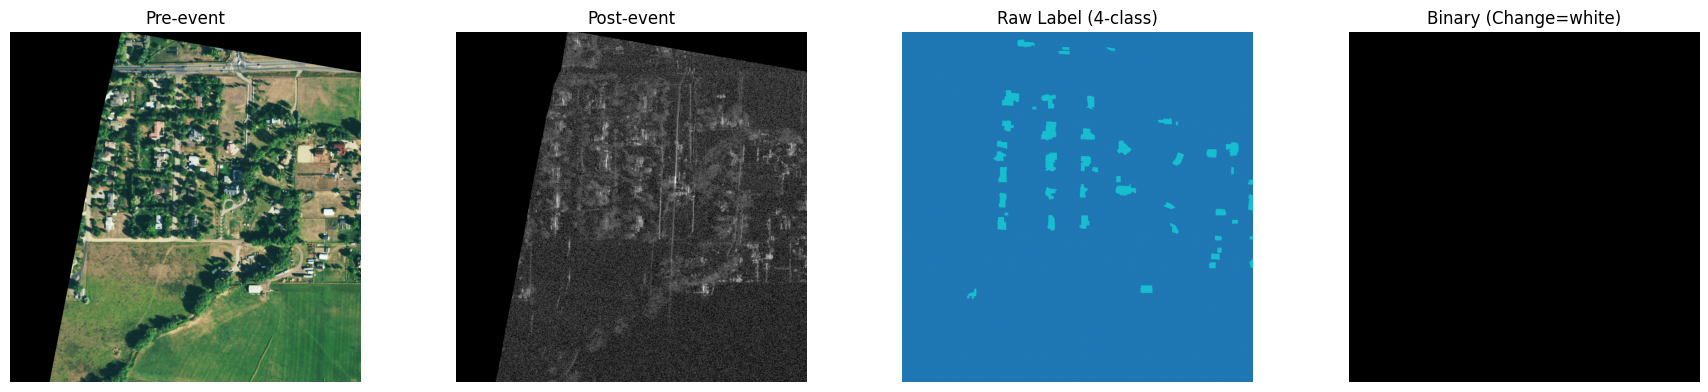

Unique raw label values: [0, 1]
Unique binary values   : [0]


In [6]:
def read_display(path):
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
    if data.shape[0] >= 3:
        data = data[:3]
    elif data.shape[0] == 2:
        data = np.concatenate(
            [data, np.zeros((1, *data.shape[1:]), dtype=np.float32)], axis=0)
    else:
        data = np.repeat(data, 3, axis=0)
    img = np.transpose(data, (1, 2, 0))
    return (img - img.min()) / (img.max() - img.min() + 1e-6)

def remap_label(mask):
    out = np.zeros_like(mask, dtype=np.uint8)
    out[mask >= 2] = 1
    return out

pre_img  = read_display(os.path.join(TEST_PRE,  sample_pre))
post_img = read_display(os.path.join(TEST_POST, sample_post))
with rasterio.open(os.path.join(TEST_MASK, sample_mask)) as src:
    raw_mask = src.read(1)
bin_mask = remap_label(raw_mask)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(pre_img);  axes[0].set_title('Pre-event')
axes[1].imshow(post_img); axes[1].set_title('Post-event')
axes[2].imshow(raw_mask, cmap='tab10'); axes[2].set_title('Raw Label (4-class)')
axes[3].imshow(bin_mask, cmap='gray');  axes[3].set_title('Binary (Change=white)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(DATA_ROOT, '..', 'sample.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Unique raw label values:', np.unique(raw_mask).tolist())
print('Unique binary values   :', np.unique(bin_mask).tolist())


## CELL 7 — Class Distribution (fast, 50-sample estimate)

In [7]:
import random
from collections import Counter

mask_files  = sorted(os.listdir(TRAIN_MASK))
sample_size = min(50, len(mask_files))
sampled     = random.sample(mask_files, sample_size)

label_counts = Counter()
for fname in sampled:
    with rasterio.open(os.path.join(TRAIN_MASK, fname)) as src:
        mask = src.read(1)
    for v, c in zip(*np.unique(mask, return_counts=True)):
        label_counts[int(v)] += int(c)

total = sum(label_counts.values())
NAMES = {0: 'Background', 1: 'Intact', 2: 'Damaged', 3: 'Destroyed'}
print(f'Estimated from {sample_size} random masks:')
for cls, cnt in sorted(label_counts.items()):
    print(f'  Class {cls} ({NAMES.get(cls,"?"):>11}): {100*cnt/total:.2f}%')

change    = label_counts.get(2, 0) + label_counts.get(3, 0)
no_change = label_counts.get(0, 0) + label_counts.get(1, 0)
print(f'\n  No-Change : {100*no_change/total:.1f}%')
print(f'  Change    : {100*change/total:.1f}%')
print(f'  Imbalance : {no_change/max(change,1):.1f}:1  → handled by Focal+Dice loss')


Estimated from 50 random masks:
  Class 0 ( Background): 86.06%
  Class 1 (     Intact): 13.39%
  Class 2 (    Damaged): 0.33%
  Class 3 (  Destroyed): 0.22%

  No-Change : 99.4%
  Change    : 0.6%
  Imbalance : 180.0:1  → handled by Focal+Dice loss


## CELL 8 — Configuration

In [8]:
import yaml, torch, random

if os.path.exists('/content'):
    OUT_DIR  = '/content'
    CKPT_DIR = '/content/checkpoints'
else:
    OUT_DIR  = '/kaggle/working'
    CKPT_DIR = '/kaggle/working/checkpoints'

os.makedirs(CKPT_DIR, exist_ok=True)

CONFIG = {
    'data_root'   : DATA_ROOT,
    'out_dir'     : OUT_DIR,
    'ckpt_dir'    : CKPT_DIR,
    'image_size'  : 256,
    'in_channels' : IN_CHANNELS,
    'n_bands'     : N_BANDS,
    'encoder'     : 'resnet34',
    'epochs'      : 30,
    'batch_size'  : 8,
    'lr'          : 1e-4,
    'weight_decay': 1e-4,
    'focal_gamma' : 2.0,
    'focal_w'     : 0.5,
    'dice_w'      : 0.5,
    'threshold'   : 0.5,
    'seed'        : 42,
    'num_workers' : 2,
    'max_samples' : 1000,   # train subset (compute constraint)
}

with open(os.path.join(OUT_DIR, 'config.yaml'), 'w') as f:
    yaml.dump(CONFIG, f)

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  No GPU! Runtime → Change runtime type → T4 GPU')
print(f'IN_CHANNELS : {IN_CHANNELS}')
print(f'Max samples : {CONFIG["max_samples"]} (train only)')
print('config.yaml saved.')


Device      : cuda
GPU         : Tesla T4
VRAM        : 15.6 GB
IN_CHANNELS : 4
Max samples : 1000 (train only)
config.yaml saved.


## CELL 9 — Dataset & DataLoader

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A


def load_all_bands(path):
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
    return np.transpose(data, (1, 2, 0))   # H,W,C


def normalize_channels(img):
    for c in range(img.shape[-1]):
        mn, mx = img[..., c].min(), img[..., c].max()
        img[..., c] = (img[..., c] - mn) / (mx - mn + 1e-6)
    return img


def remap(mask):
    out = np.zeros_like(mask, dtype=np.uint8)
    out[mask >= 2] = 1
    return out


class ChangeDetectionDataset(Dataset):
    def __init__(self, pre_dir, post_dir, mask_dir,
                 image_size=256, augment=False, max_samples=None):
        self.pre_dir  = pre_dir
        self.post_dir = post_dir
        self.mask_dir = mask_dir
        self.sz       = image_size

        self.pre_files  = sorted(os.listdir(pre_dir))
        self.post_files = sorted(os.listdir(post_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

        assert len(self.pre_files) == len(self.post_files) == len(self.mask_files), \
            f'Mismatch: pre={len(self.pre_files)}, ' \
            f'post={len(self.post_files)}, mask={len(self.mask_files)}'

        if max_samples and max_samples < len(self.pre_files):
            total   = len(self.pre_files)
            indices = sorted(random.sample(range(total), max_samples))
            self.pre_files  = [self.pre_files[i]  for i in indices]
            self.post_files = [self.post_files[i] for i in indices]
            self.mask_files = [self.mask_files[i] for i in indices]
            print(f'  Subsampled: {max_samples} / {total} train samples used')

        if augment:
            self.tf = A.Compose([
                A.RandomCrop(image_size, image_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(
                    brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            ])
        else:
            self.tf = A.Compose([A.CenterCrop(image_size, image_size)])

    def __len__(self):
        return len(self.pre_files)

    def __getitem__(self, idx):
        pre  = load_all_bands(os.path.join(self.pre_dir,  self.pre_files[idx]))
        post = load_all_bands(os.path.join(self.post_dir, self.post_files[idx]))
        img  = normalize_channels(np.concatenate([pre, post], axis=-1))

        with rasterio.open(os.path.join(self.mask_dir, self.mask_files[idx])) as src:
            raw = src.read(1)
        mask = remap(raw)

        # Pad if smaller than crop size
        h, w = img.shape[:2]
        if h < self.sz or w < self.sz:
            pad_h = max(0, self.sz - h)
            pad_w = max(0, self.sz - w)
            img  = np.pad(img,  ((0,pad_h),(0,pad_w),(0,0)), mode='reflect')
            mask = np.pad(mask, ((0,pad_h),(0,pad_w)),        mode='reflect')

        out  = self.tf(image=img, mask=mask)
        img  = out['image']
        mask = out['mask']

        return (torch.from_numpy(img.transpose(2, 0, 1)).float(),
                torch.from_numpy(mask).long())


train_ds = ChangeDetectionDataset(
    TRAIN_PRE, TRAIN_POST, TRAIN_MASK,
    CONFIG['image_size'], augment=True,
    max_samples=CONFIG['max_samples'])

val_ds = ChangeDetectionDataset(
    VAL_PRE, VAL_POST, VAL_MASK,
    CONFIG['image_size'], augment=False, max_samples=None)

test_ds = ChangeDetectionDataset(
    TEST_PRE, TEST_POST, TEST_MASK,
    CONFIG['image_size'], augment=False, max_samples=None)

PIN = torch.cuda.is_available()

train_dl = DataLoader(train_ds, CONFIG['batch_size'], shuffle=True,
                      num_workers=CONFIG['num_workers'], pin_memory=PIN)
val_dl   = DataLoader(val_ds,   CONFIG['batch_size'], shuffle=False,
                      num_workers=CONFIG['num_workers'], pin_memory=PIN)
test_dl  = DataLoader(test_ds,  CONFIG['batch_size'], shuffle=False,
                      num_workers=CONFIG['num_workers'], pin_memory=PIN)

print(f'Train : {len(train_ds):>6,} samples')
print(f'Val   : {len(val_ds):>6,} samples')
print(f'Test  : {len(test_ds):>6,} samples')

imgs, masks = next(iter(train_dl))
print(f'\nBatch  — images: {tuple(imgs.shape)}  masks: {tuple(masks.shape)}')
print(f'Mask unique    : {masks.unique().tolist()}')
print(f'Channels OK    : {imgs.shape[1] == CONFIG["in_channels"]}')


  Subsampled: 1000 / 2781 train samples used
Train :  1,000 samples
Val   :    334 samples
Test  :     77 samples

Batch  — images: (8, 4, 256, 256)  masks: (8, 256, 256)
Mask unique    : [0]
Channels OK    : True


## CELL 10 — Model: UNet + ResNet34

In [10]:
import torch.nn as nn
import segmentation_models_pytorch as smp


class ChangeDetectionModel(nn.Module):
    """
    UNet with ImageNet-pretrained ResNet34 encoder.
    Early fusion: pre+post channels concatenated as input.
    Output: single-channel sigmoid logits → binary change map.
    """
    def __init__(self, in_channels, encoder='resnet34'):
        super().__init__()
        self.net = smp.Unet(
            encoder_name    = encoder,
            encoder_weights = 'imagenet',
            in_channels     = in_channels,
            classes         = 1,
            activation      = None,
        )

    def forward(self, x):
        return self.net(x)   # (B, 1, H, W)


model = ChangeDetectionModel(
    in_channels = CONFIG['in_channels'],
    encoder     = CONFIG['encoder']
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model      : UNet + ResNet34 (ImageNet pretrained)')
print(f'Parameters : {n_params:,}')
print(f'Input ch   : {CONFIG["in_channels"]}')

with torch.no_grad():
    dummy = torch.randn(2, CONFIG['in_channels'],
                        CONFIG['image_size'], CONFIG['image_size']).to(DEVICE)
    out = model(dummy)
    print(f'Forward    : {tuple(dummy.shape)} → {tuple(out.shape)}  ✅')


Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 162MB/s]


Model      : UNet + ResNet34 (ImageNet pretrained)
Parameters : 24,439,505
Input ch   : 4
Forward    : (2, 4, 256, 256) → (2, 1, 256, 256)  ✅


## CELL 11 — Loss Functions (Focal + Dice)

In [12]:
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        logits  = logits.squeeze(1).float()
        targets = targets.float()
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs   = torch.sigmoid(logits)
        p_t     = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = torch.sigmoid(logits.squeeze(1))
        targets = targets.float()
        inter   = (probs * targets).sum(dim=(1, 2))
        union   = probs.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))
        return 1 - ((2 * inter + self.smooth) / (union + self.smooth)).mean()


class FocalDiceLoss(nn.Module):
    def __init__(self, focal_w=0.5, dice_w=0.5, gamma=2.0):
        super().__init__()
        self.fw    = focal_w
        self.dw    = dice_w
        self.focal = FocalLoss(gamma=gamma)
        self.dice  = DiceLoss()

    def forward(self, logits, targets):
        return self.fw * self.focal(logits, targets) + \
               self.dw * self.dice(logits, targets)


criterion = FocalDiceLoss(
    focal_w = CONFIG['focal_w'],
    dice_w  = CONFIG['dice_w'],
    gamma   = CONFIG['focal_gamma']
).to(DEVICE)

print('Loss: 0.5 x FocalLoss(gamma=2) + 0.5 x DiceLoss')
print('Handles class imbalance: Focal down-weights easy negatives, Dice optimises IoU.')

Loss: 0.5 x FocalLoss(gamma=2) + 0.5 x DiceLoss
Handles class imbalance: Focal down-weights easy negatives, Dice optimises IoU.


## CELL 12 — Optimizer, Scheduler & Metrics

In [13]:
import torch.optim as optim
from sklearn.metrics import confusion_matrix


optimizer = optim.AdamW(
    model.parameters(),
    lr           = CONFIG['lr'],
    weight_decay = CONFIG['weight_decay']
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
)


def compute_metrics(probs, labels, threshold=0.5):
    preds          = (probs >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    precision      = tp / (tp + fp + 1e-8)
    recall         = tp / (tp + fn + 1e-8)
    f1             = 2 * precision * recall / (precision + recall + 1e-8)
    iou            = tp / (tp + fp + fn + 1e-8)
    return dict(IoU=iou, Precision=precision, Recall=recall, F1=f1,
                TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn))


print('Optimizer : AdamW  (lr=1e-4, wd=1e-4)')
print('Scheduler : CosineAnnealingLR')
print('Metrics   : IoU / Precision / Recall / F1  (Change class)')


Optimizer : AdamW  (lr=1e-4, wd=1e-4)
Scheduler : CosineAnnealingLR
Metrics   : IoU / Precision / Recall / F1  (Change class)


## CELL 13 — Training Loop

In [14]:
import time, json

BEST_CKPT = os.path.join(CONFIG['ckpt_dir'], 'best_model.pth')
HIST_PATH = os.path.join(CONFIG['out_dir'],  'history.json')
history   = dict(train_loss=[], val_loss=[], val_iou=[], val_f1=[])
best_iou  = 0.0


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, masks)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            all_probs.append(
                torch.sigmoid(logits).squeeze(1).detach().cpu().numpy().ravel())
            all_labels.append(masks.cpu().numpy().ravel())

    probs   = np.concatenate(all_probs)
    labels  = np.concatenate(all_labels)
    metrics = compute_metrics(probs, labels, CONFIG['threshold'])
    return total_loss / len(loader), metrics


print(f'Training {CONFIG["epochs"]} epochs | {len(train_ds)} train samples | device: {DEVICE}')
HDR = f'{"Ep":>4} | {"T-Loss":>8} | {"V-Loss":>8} | {"V-IoU":>7} | {"V-F1":>7} | {"LR":>9} | Time'
SEP = '─' * len(HDR)
print(SEP); print(HDR); print(SEP)

for ep in range(1, CONFIG['epochs'] + 1):
    t0 = time.time()
    tr_loss, _    = run_epoch(train_dl, train=True)
    va_loss, va_m = run_epoch(val_dl,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['val_iou'].append(va_m['IoU'])
    history['val_f1'].append(va_m['F1'])

    lr = optimizer.param_groups[0]['lr']
    print(f'{ep:>4} | {tr_loss:>8.4f} | {va_loss:>8.4f} | '
          f'{va_m["IoU"]:>7.4f} | {va_m["F1"]:>7.4f} | '
          f'{lr:>9.2e} | {time.time()-t0:.0f}s')

    if va_m['IoU'] > best_iou:
        best_iou = va_m['IoU']
        torch.save({
            'epoch'      : ep,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_iou'    : best_iou,
            'config'     : CONFIG,
        }, BEST_CKPT)
        print(f'       ✅  Saved best model  (IoU={best_iou:.4f})')

    # Save history after every epoch so restarts don't lose progress
    with open(HIST_PATH, 'w') as f:
        json.dump(history, f)

print(SEP)
print(f'Done. Best Val IoU = {best_iou:.4f}')
print(f'Checkpoint : {BEST_CKPT}')
print(f'History    : {HIST_PATH}')


Training 30 epochs | 1000 train samples | device: cuda
─────────────────────────────────────────────────────────────────
  Ep |   T-Loss |   V-Loss |   V-IoU |    V-F1 |        LR | Time
─────────────────────────────────────────────────────────────────
   1 |   0.5242 |   0.4997 |  0.0054 |  0.0108 |  9.97e-05 | 66s
       ✅  Saved best model  (IoU=0.0054)
   2 |   0.5011 |   0.4949 |  0.0003 |  0.0006 |  9.89e-05 | 63s
   3 |   0.4970 |   0.4934 |  0.0216 |  0.0422 |  9.76e-05 | 62s
       ✅  Saved best model  (IoU=0.0216)
   4 |   0.4961 |   0.4931 |  0.0012 |  0.0023 |  9.57e-05 | 62s
   5 |   0.4953 |   0.4929 |  0.0430 |  0.0824 |  9.34e-05 | 61s
       ✅  Saved best model  (IoU=0.0430)
   6 |   0.4952 |   0.4934 |  0.0002 |  0.0004 |  9.05e-05 | 62s
   7 |   0.4942 |   0.4899 |  0.1298 |  0.2298 |  8.73e-05 | 62s
       ✅  Saved best model  (IoU=0.1298)
   8 |   0.4938 |   0.4892 |  0.1429 |  0.2501 |  8.36e-05 | 62s
       ✅  Saved best model  (IoU=0.1429)
   9 |   0.4931 |   0.

## CELL 14 — Training Curves

Using in-memory history.


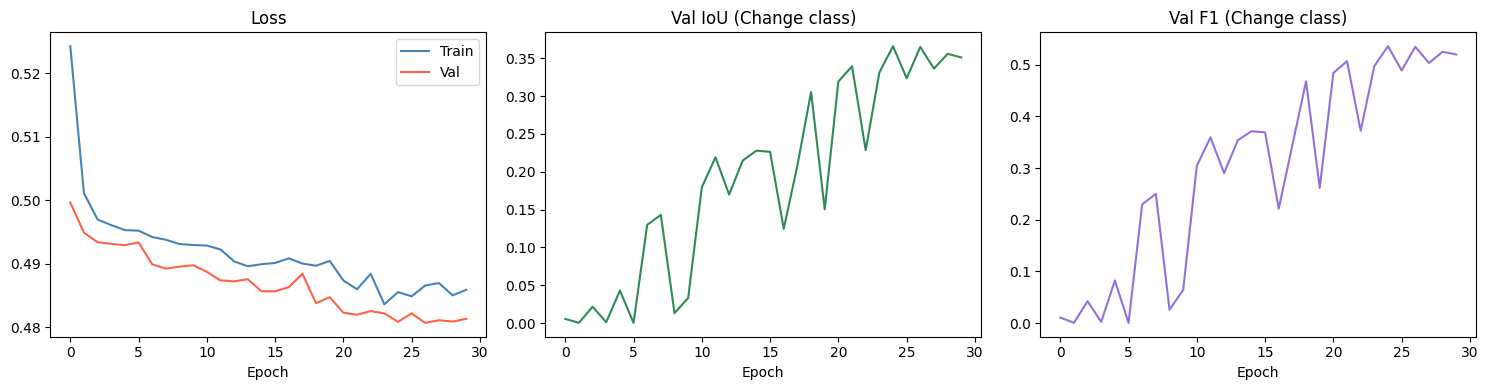

Saved training_curves.png


In [15]:
import json

# ── Robust load: uses in-memory history OR loads from disk ──
HIST_PATH = os.path.join(CONFIG['out_dir'], 'history.json')

try:
    assert len(history['train_loss']) > 0
    print('Using in-memory history.')
except (NameError, AssertionError):
    with open(HIST_PATH) as f:
        history = json.load(f)
    print(f'Loaded history from disk: {HIST_PATH}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_iou'], color='seagreen')
axes[1].set_title('Val IoU (Change class)'); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_f1'], color='mediumpurple')
axes[2].set_title('Val F1 (Change class)'); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['out_dir'], 'training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')


## CELL 15 — Final Evaluation on Val + Test

Loaded epoch 25  (Val IoU=0.3660)

╔══ Validation ══╗
  IoU         : 0.3660
  Precision   : 0.5162
  Recall      : 0.5570
  F1          : 0.5359
  TP=408,341  FP=382,642  FN=324,702  TN=20,773,339


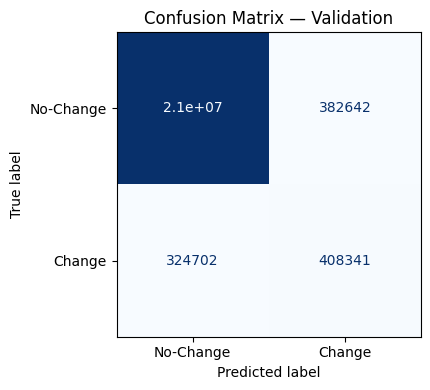


╔══ Test ══╗
  IoU         : 0.0637
  Precision   : 0.1079
  Recall      : 0.1344
  F1          : 0.1197
  TP=5,209  FP=43,083  FN=33,539  TN=4,964,441


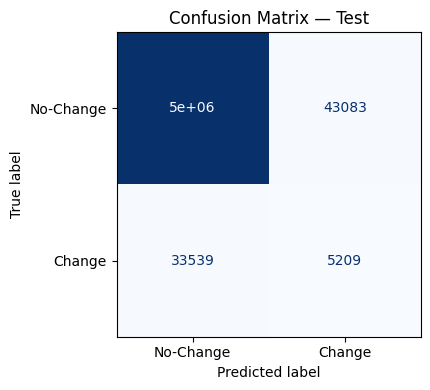


══════════════════════════════════════════════════
Metric              Validation            Test
──────────────────────────────────────────────────
IoU                     0.3660          0.0637
Precision               0.5162          0.1079
Recall                  0.5570          0.1344
F1                      0.5359          0.1197
══════════════════════════════════════════════════


In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

BEST_CKPT = os.path.join(CONFIG['ckpt_dir'], 'best_model.pth')

# weights_only=False required for PyTorch >= 2.6
ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded epoch {ckpt["epoch"]}  (Val IoU={ckpt["val_iou"]:.4f})')


def full_evaluate(loader, name):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, masks in loader:
            logits = model(imgs.to(DEVICE))
            all_probs.append(
                torch.sigmoid(logits).squeeze(1).cpu().numpy().ravel())
            all_labels.append(masks.numpy().ravel())

    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    m      = compute_metrics(probs, labels, CONFIG['threshold'])

    print(f'\n╔══ {name} ══╗')
    for k in ['IoU', 'Precision', 'Recall', 'F1']:
        print(f'  {k:<12}: {m[k]:.4f}')
    print(f'  TP={m["TP"]:,}  FP={m["FP"]:,}  FN={m["FN"]:,}  TN={m["TN"]:,}')

    cm = confusion_matrix(labels,
                          (probs >= CONFIG['threshold']).astype(np.uint8),
                          labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['No-Change','Change']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['out_dir'], f'cm_{name.lower()}.png'), dpi=150)
    plt.show()
    return m


val_m  = full_evaluate(val_dl,  'Validation')
test_m = full_evaluate(test_dl, 'Test')

print()
print('═' * 50)
print(f'{"Metric":<12} {"Validation":>17} {"Test":>15}')
print('─' * 50)
for k in ['IoU', 'Precision', 'Recall', 'F1']:
    print(f'{k:<12} {val_m[k]:>17.4f} {test_m[k]:>15.4f}')
print('═' * 50)


## CELL 16 — Qualitative Predictions (6 examples)

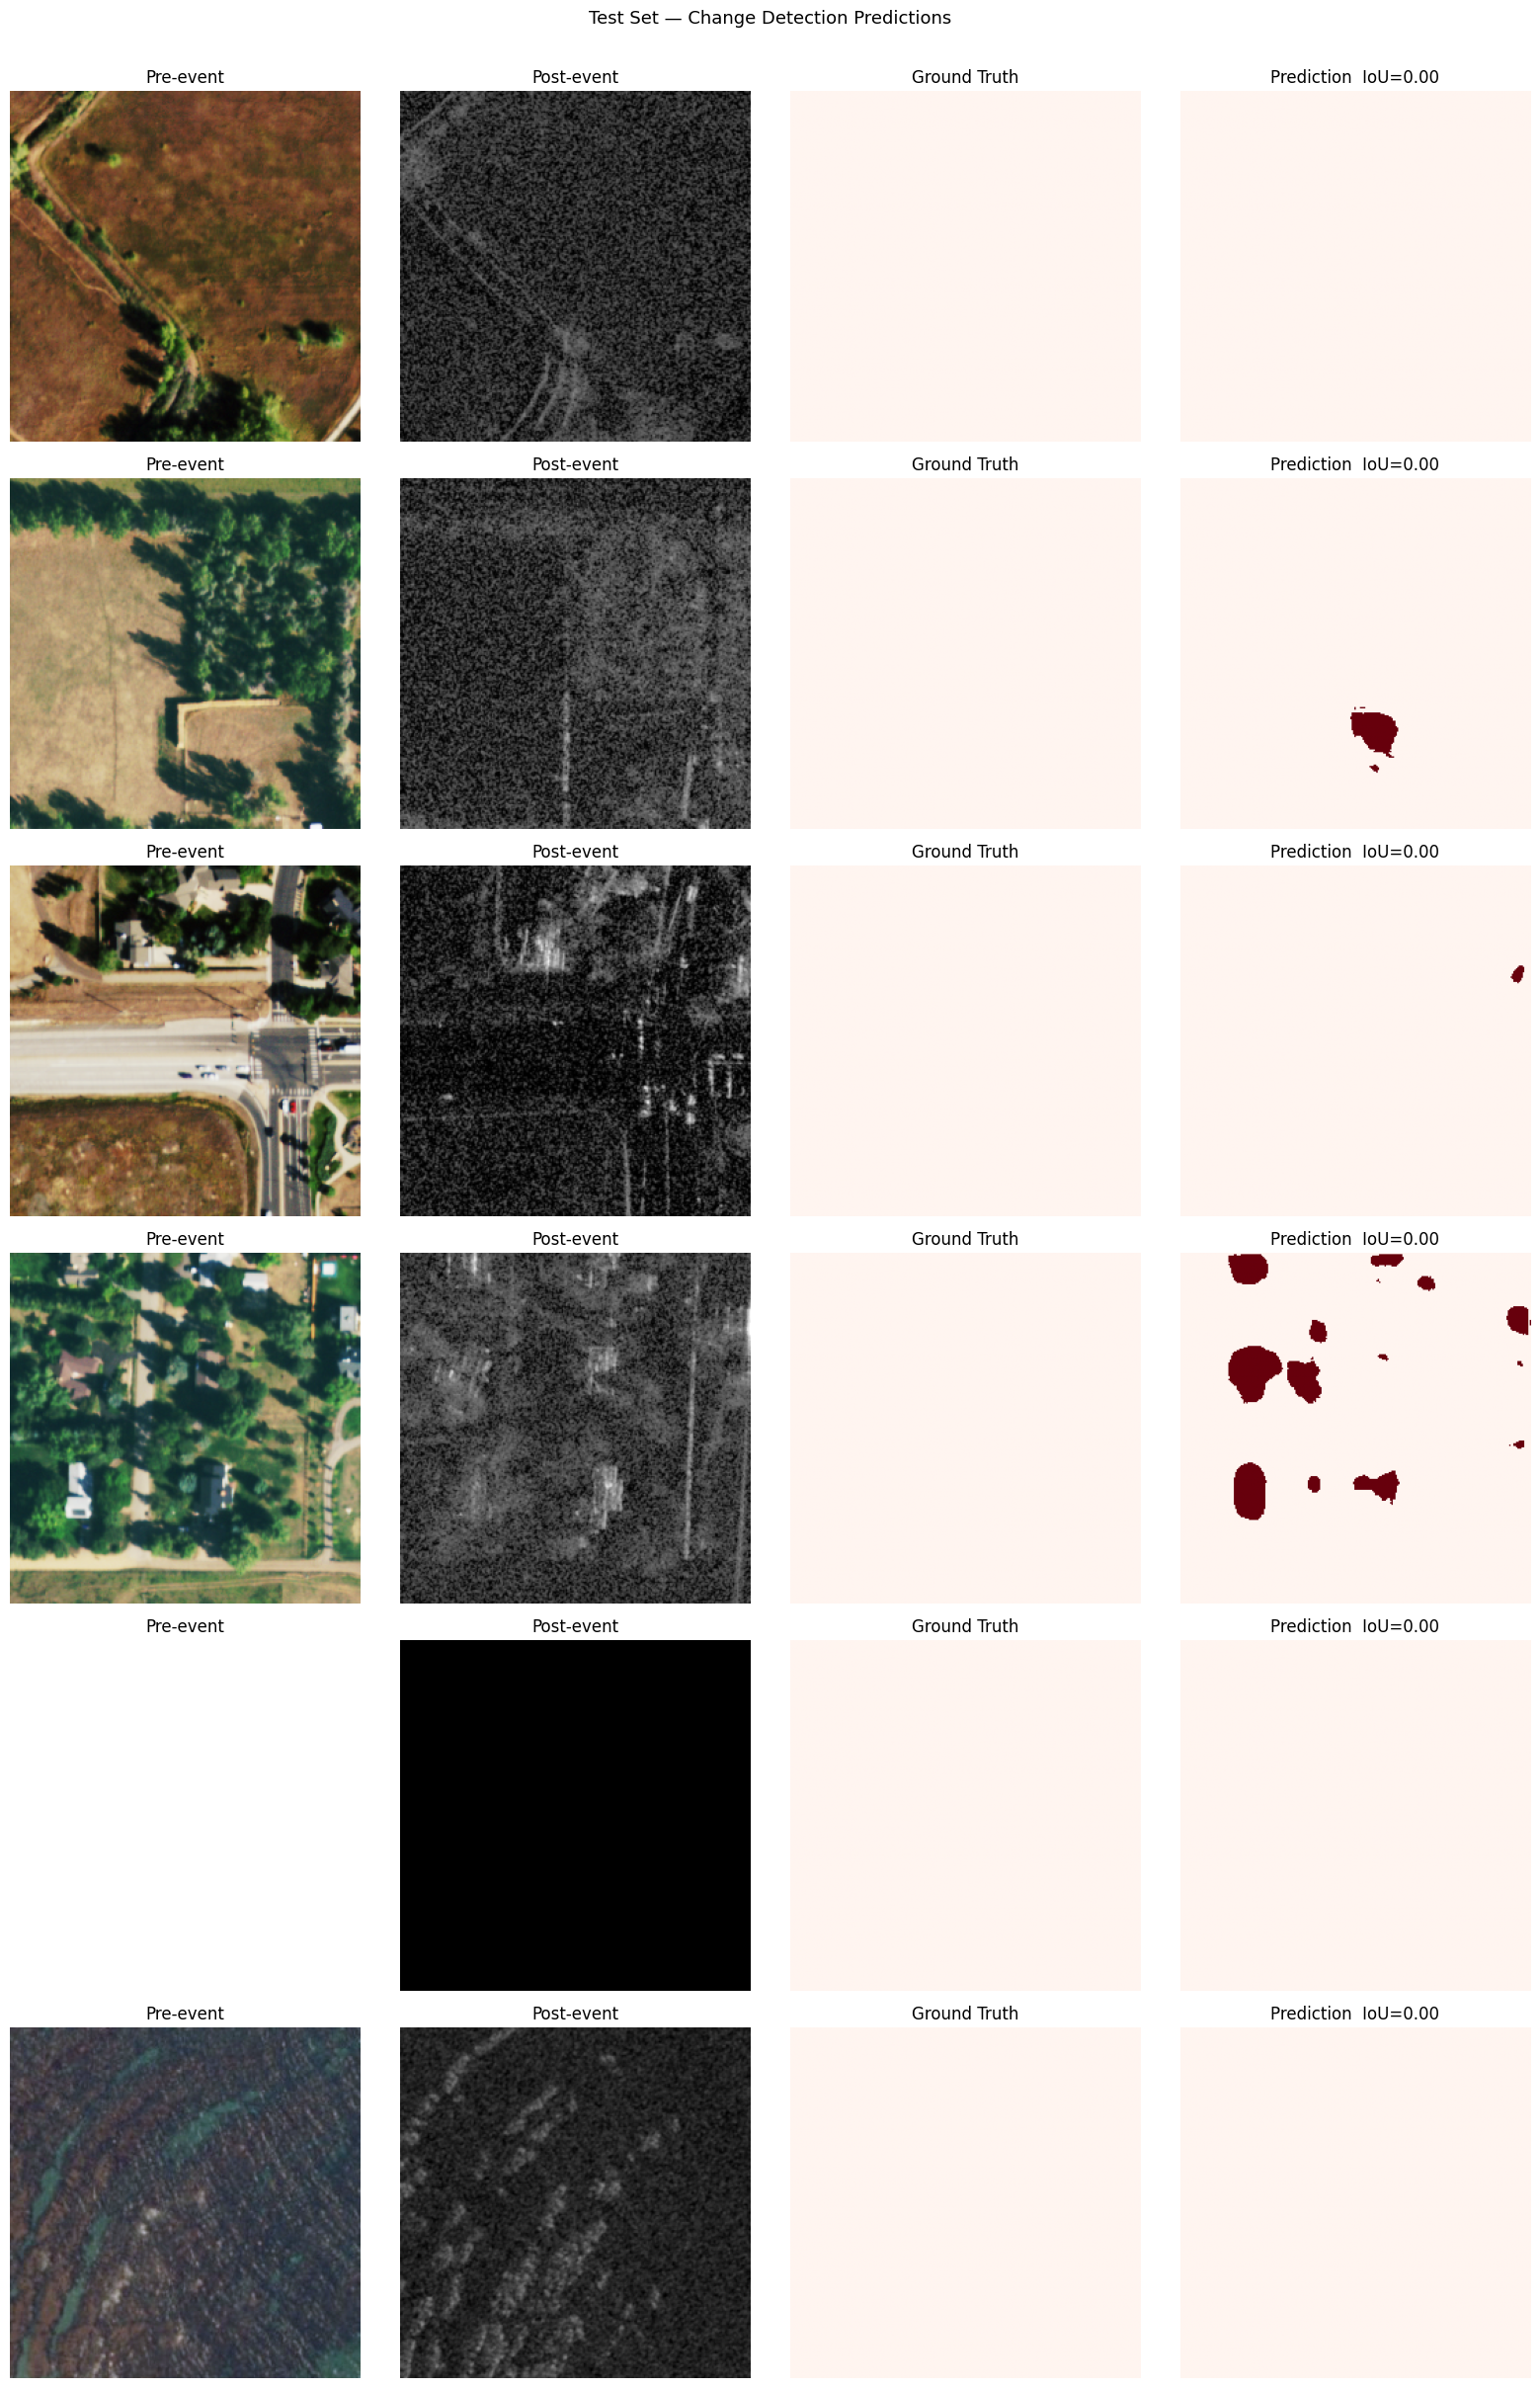

Saved predictions.png


In [17]:
model.eval()
NB = CONFIG['n_bands']
N  = 6
indices = np.random.choice(len(test_ds), N, replace=False)
fig, axes = plt.subplots(N, 4, figsize=(16, N * 4))


def to_rgb(tensor_chw):
    arr = tensor_chw.permute(1, 2, 0).numpy().clip(0, 1)
    if arr.shape[-1] >= 3:   return arr[..., :3]
    elif arr.shape[-1] == 2: return np.concatenate(
        [arr, np.zeros((*arr.shape[:2], 1), np.float32)], axis=-1)
    else:                    return np.repeat(arr, 3, axis=-1)


for row, idx in enumerate(indices):
    img_t, mask_t = test_ds[idx]

    with torch.no_grad():
        logit = model(img_t.unsqueeze(0).to(DEVICE))
        prob  = torch.sigmoid(logit).squeeze().cpu().numpy()

    pred = (prob >= CONFIG['threshold']).astype(np.uint8)
    gt   = mask_t.numpy()

    pre_rgb  = to_rgb(img_t[:NB])
    post_rgb = to_rgb(img_t[NB:NB*2])
    iou_s    = np.logical_and(pred,gt).sum() / (np.logical_or(pred,gt).sum() + 1e-8)

    axes[row,0].imshow(pre_rgb);  axes[row,0].set_title('Pre-event')
    axes[row,1].imshow(post_rgb); axes[row,1].set_title('Post-event')
    axes[row,2].imshow(gt,   cmap='Reds', vmin=0, vmax=1)
    axes[row,2].set_title('Ground Truth')
    axes[row,3].imshow(pred, cmap='Reds', vmin=0, vmax=1)
    axes[row,3].set_title(f'Prediction  IoU={iou_s:.2f}')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Test Set — Change Detection Predictions', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['out_dir'], 'predictions.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Saved predictions.png')


## CELL 17 — Save results.json & Checklist

In [18]:
import json

results = {
    'best_epoch' : int(ckpt['epoch']),
    'validation' : {k: float(v) for k, v in val_m.items()},
    'test'       : {k: float(v) for k, v in test_m.items()},
    'config'     : CONFIG,
}
with open(os.path.join(CONFIG['out_dir'], 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print('Output files:')
for fname in sorted(os.listdir(CONFIG['out_dir'])):
    fp = os.path.join(CONFIG['out_dir'], fname)
    if os.path.isfile(fp):
        print(f'  {fname:<45} {os.path.getsize(fp)/1e6:>8.2f} MB')

print('\nCheckpoint:')
for fname in os.listdir(CONFIG['ckpt_dir']):
    fp = os.path.join(CONFIG['ckpt_dir'], fname)
    print(f'  {fname:<45} {os.path.getsize(fp)/1e6:>8.2f} MB')

print('\n✅  Post-training checklist:')
print('  [ ] Download checkpoints/best_model.pth')
print('  [ ] Upload weights to Google Drive or HuggingFace Hub')
print('  [ ] Paste public link into README.md')
print('  [ ] Copy metrics from results.json into report')
print('  [ ] Include training_curves.png + predictions.png in report')


Output files:
  cm_test.png                                       0.03 MB
  cm_validation.png                                 0.03 MB
  config.yaml                                       0.00 MB
  history.json                                      0.00 MB
  predictions.png                                   3.19 MB
  results.json                                      0.00 MB
  sample.png                                        0.74 MB
  training_curves.png                               0.12 MB

Checkpoint:
  best_model.pth                                  293.57 MB

✅  Post-training checklist:
  [ ] Download checkpoints/best_model.pth
  [ ] Upload weights to Google Drive or HuggingFace Hub
  [ ] Paste public link into README.md
  [ ] Copy metrics from results.json into report
  [ ] Include training_curves.png + predictions.png in report
